In [1]:
import pandas as pd
import string
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV

In [2]:
def remove_punctuation(text):
    cleaned = ''.join([word for word in text if word not in string.punctuation])
    return cleaned
def tokenize(text):
    clean_text = text.lower()
    tokenized_text = nltk.word_tokenize(clean_text)
    return tokenized_text
def remove_stop_words(text):
    without_stopwords = [word for word in text if word not in stopwords]
    return without_stopwords
stemmer = nltk.PorterStemmer()
def stemming(text):
    stemmed_words = [stemmer.stem(word) for word in text]
    return stemmed_words
lemmater = nltk.WordNetLemmatizer()
def lemmatizing(text):
    lemmatized_words = [lemmater.lemmatize(word) for word in text]
    return lemmatized_words

In [3]:
spam_dataset = pd.read_csv('spam.csv', encoding = 'ISO-8859-1', usecols=[0,1], names = ['Spam', 'Text'],skiprows=1)
spam_dataset['Spam'] = spam_dataset['Spam'].replace(['ham','spam'],[0,1])
spam_dataset['Cleaned_Text'] = spam_dataset['Text'].apply(lambda x: remove_punctuation(x))
spam_dataset['Tokenized_Text'] = spam_dataset['Cleaned_Text'].apply(lambda x: tokenize(x))
stopwords = nltk.corpus.stopwords.words("english")
spam_dataset['WithoutStop_Text'] = spam_dataset['Tokenized_Text'].apply(lambda x: remove_stop_words(x))
spam_dataset['Stemmed_Text'] = spam_dataset['WithoutStop_Text'].apply(lambda x: stemming(x))
spam_dataset['Lemmatized_Text'] = spam_dataset['WithoutStop_Text'].apply(lambda x: lemmatizing(x))

C:\Users\abram\AppData\Local\Temp\ipykernel_26536\1420970882.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  spam_dataset['Spam'] = spam_dataset['Spam'].replace(['ham','spam'],[0,1])


CountVectorizer

In [4]:
X = spam_dataset['Lemmatized_Text'].apply(lambda x: ' '.join(x))
y = spam_dataset['Spam']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2,stratify=y, random_state=0)
count = CountVectorizer(min_df=0.01,max_df=0.5)
X_train_count = count.fit_transform(X_train)
X_test_count = count.transform(X_test)
cls = RandomForestClassifier(random_state=0)
cls.fit(X_train_count,y_train)
y_pred = cls.predict(X_test_count)
print('f1 score =',f1_score(y_test,y_pred))
feature_names = count.get_feature_names_out()
mdi_importances = pd.Series(cls.feature_importances_, index=feature_names)
print('MDI Count-\n',mdi_importances.nlargest(20))

feature_importances = cls.feature_importances_
selected_importances_mask = feature_importances > 0.001

X_train_selected = X_train_count[:,selected_importances_mask]
X_test_selected = X_test_count[:,selected_importances_mask]

random_forest = RandomForestClassifier(n_estimators=1000, n_jobs=-1,random_state=0)
params_rf = {   
    "max_depth": [30],
    "min_samples_split": [2],
    "min_samples_leaf": [1],
    "max_features": ["sqrt"],
    "class_weight": [None]
            }
rf_gridsearch = GridSearchCV(random_forest,
                             params_rf,
                             scoring='f1_macro',
                             cv=5,
                             verbose=10, n_jobs=-1)
rf_gridsearch.fit(X_train_selected, y_train)
print('\nBest hyperparameter:', rf_gridsearch.best_params_)
rf_model_v2 = rf_gridsearch.best_estimator_
y_pred = rf_gridsearch.predict(X_test_selected)
print('f1 score =',f1_score(y_test,y_pred))

f1 score = 0.8382352941176471
MDI Count-
 call       0.119762
txt        0.095958
free       0.053060
claim      0.047560
mobile     0.044762
text       0.034949
prize      0.031109
stop       0.031017
service    0.030769
reply      0.029964
tone       0.027333
win        0.025916
cash       0.025235
urgent     0.021928
ur         0.017045
contact    0.015090
per        0.012971
new        0.012510
send       0.012452
min        0.011876
dtype: float64
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best hyperparameter: {'class_weight': None, 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
f1 score = 0.8296296296296296


TfidfVectorizer

In [5]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

cls_tfidV = RandomForestClassifier(random_state=0)
cls_tfidV.fit(X_train_tfidf,y_train)
y_pred = cls_tfidV.predict(X_test_tfidf)
print('f1 score =',f1_score(y_test,y_pred))
feature_names = tfidf.get_feature_names_out()
mdi_importances = pd.Series(cls_tfidV.feature_importances_, index=feature_names)
print('MDI  TFID-\n',mdi_importances.nlargest(20))

feature_importances = cls_tfidV.feature_importances_
selected_importances_mask = feature_importances > 0.001

X_train_selected = X_train_tfidf[:,selected_importances_mask]
X_test_selected = X_test_tfidf[:,selected_importances_mask]

random_forest = RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=0)
params_rf = {   
    "max_depth": [50],
    "min_samples_split": [5],
    "min_samples_leaf": [1],
    "max_features": ["sqrt"],
    "class_weight": [None]
            }
rf_gridsearch = GridSearchCV(random_forest,
                             params_rf,
                             scoring='f1_macro',
                             cv=5,
                             verbose=10, n_jobs=-1)
rf_gridsearch.fit(X_train_selected, y_train)
print('\nBest hyperparameter:', rf_gridsearch.best_params_)
rf_model_v2 = rf_gridsearch.best_estimator_
y_pred = rf_gridsearch.predict(X_test_selected)
print('f1 score =',f1_score(y_test,y_pred))

f1 score = 0.8669201520912547
MDI  TFID-
 call        0.034813
txt         0.029642
free        0.024584
claim       0.024470
prize       0.016797
mobile      0.016731
service     0.016600
stop        0.015312
win         0.012798
reply       0.012557
text        0.012536
tone        0.012376
18          0.011253
urgent      0.010900
500         0.010595
contact     0.010095
customer    0.008475
1000        0.008205
landline    0.008023
cash        0.007006
dtype: float64
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best hyperparameter: {'class_weight': None, 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5}
f1 score = 0.8773234200743495


TF-IDF dał lepszy wynik niż CountVectorizer. Dla CountVectorizer wynik lekko spadł z 0.838 do 0.830, więc selekcja usunęła część przydatnej informacji. Po selekcji i GridSearch wynik TF-IDF wzrósł z 0.867 do 0.877

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.98      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



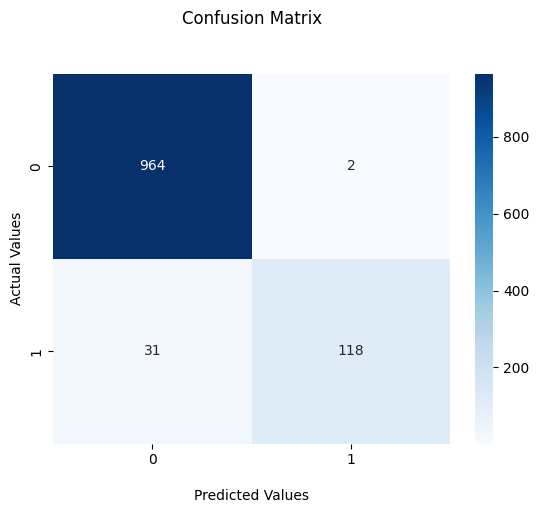

,Model,F1_score
0,TfidVectorizer + RandomForest + GridSearch,0.969027


In [8]:
from calculate_metrics import calculate_metrics

calculate_metrics(rf_gridsearch,'TfidVectorizer + RandomForest + GridSearch', X_test_selected,y_test)

Model prawie idealnie klasyfikuje wiadomości prawidłowe (964) jednak dwie zostały uznane za spam. Natomiast prawidłowo wykrył spam dla 118 maili ale nie rozpoznał 31 maili jako spam i zaklasyfikował do prawidłowych